## Sample and Calibrator Dispersion on Candia

### Background

### Setup

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [34]:
samples = pd.read_table("../data/candia/sample.txt")
somamer = pd.read_table("../data/candia/somamer.txt")
measurements = pd.read_table("../data/candia/RFU_hyb.msnCal.ps.cal.msnAll.txt", header=None)

measurements.columns = somamer["SeqId"]
measurements = pd.concat(
    [measurements, samples[["PlateId", "PlatePosition"]]],
    axis=1
)
measurements = measurements.melt(id_vars = ["PlateId", "PlatePosition"], var_name="SeqId")

In [35]:
measurements

,PlateId,PlatePosition,SeqId,value
0,P0031168,A1,10000-28,799.4335
1,P0031168,A10,10000-28,570.5529
2,P0031168,A11,10000-28,588.3089
3,P0031168,A12,10000-28,523.9531
4,P0031168,A2,10000-28,524.6928
...,...,...,...,...
15571795,P0031201,H5,9999-1,2101.9930
15571796,P0031201,H6,9999-1,1470.0940
15571797,P0031201,H7,9999-1,4454.8860
15571798,P0031201,H8,9999-1,4037.3190


### Calibrator Dispersion

In [47]:
calibrator_measurements = (
    samples.loc[samples.SampleType == "Calibrator", ["PlateId", "PlatePosition"]]
           .merge(measurements)
           .merge(somamer.loc[np.logical_and(somamer.Organism == "Human", somamer.Type == "Protein"), "SeqId"])
)

In [50]:
calibrator_cv_by_plate = (
    100 * calibrator_measurements.groupby(["PlateId", "SeqId"]).value.std() / calibrator_measurements.groupby(["PlateId", "SeqId"]).value.mean()
).rename("cv").to_frame().reset_index()
calibrator_cv_by_plate

,PlateId,SeqId,cv
0,P0031168,10000-28,1.198439
1,P0031168,10001-7,3.208998
2,P0031168,10003-15,5.038967
3,P0031168,10006-25,1.209880
4,P0031168,10008-43,1.323014
...,...,...,...
160331,P0031202,9993-11,1.083247
160332,P0031202,9994-217,0.463707
160333,P0031202,9995-6,1.139470
160334,P0031202,9997-12,3.281172


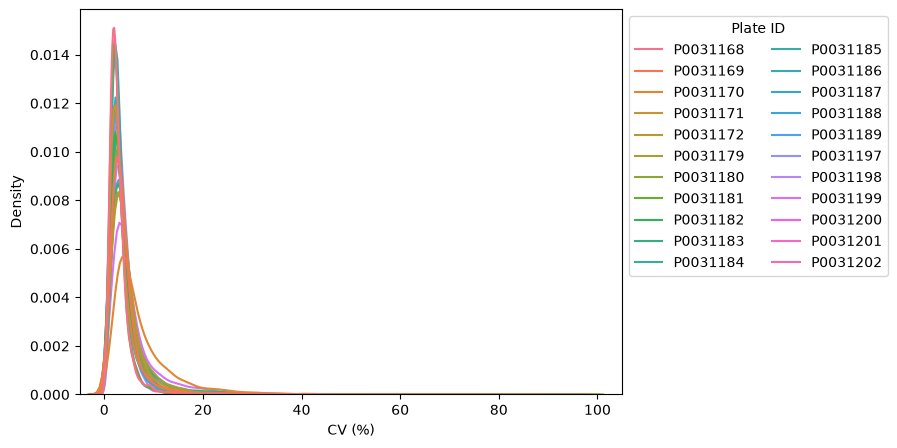

In [125]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=calibrator_cv_by_plate[calibrator_cv_by_plate.cv < 100],
    x="cv",
    hue="PlateId"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(
    handles,
    labels,
    title="Plate ID",
    ncol=2,
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.xlim(-5, 105)

plt.show()

In [68]:
calibrator_measurements_deduplicated = (
    calibrator_measurements.sort_values(["PlateId", "PlatePosition"])
                           .drop_duplicates(["PlateId", "SeqId"])
)
calibrator_measurements_deduplicated

,PlateId,PlatePosition,SeqId,value
0,P0031168,A9,10000-28,893.2555
1,P0031168,A9,10001-7,403.4078
2,P0031168,A9,10003-15,227.4742
3,P0031168,A9,10006-25,841.5257
4,P0031168,A9,10008-43,743.2851
...,...,...,...,...
699643,P0031202,A9,9993-11,1709.2900
699644,P0031202,A9,9994-217,2076.2660
699645,P0031202,A9,9995-6,2370.9650
699646,P0031202,A9,9997-12,7409.7340


In [69]:
calibrator_cv_across_plates = (
    100 * calibrator_measurements_deduplicated.groupby("SeqId").value.std() / calibrator_measurements_deduplicated.groupby("SeqId").value.mean()
).rename("cv").to_frame().reset_index()
calibrator_cv_across_plates

,SeqId,cv
0,10000-28,1.649686
1,10001-7,1.824844
2,10003-15,5.187689
3,10006-25,1.746308
4,10008-43,1.527489
...,...,...
7283,9993-11,3.405568
7284,9994-217,1.591657
7285,9995-6,2.003880
7286,9997-12,4.045927


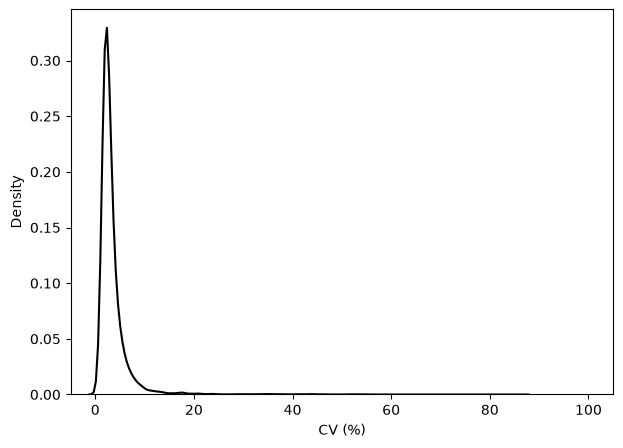

In [126]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=calibrator_cv_across_plates[calibrator_cv_across_plates.cv < 100],
    x="cv",
    c = "black"
)

plt.xlabel("CV (%)")
plt.xlim(-5, 105)
plt.show()

### Sample Dispersion

In [75]:
sample_measurements = (
    samples.loc[samples.SampleType == "Sample", ["PlateId", "PlatePosition"]]
           .merge(measurements)
           .merge(somamer.loc[np.logical_and(somamer.Organism == "Human", somamer.Type == "Protein"), "SeqId"])
)

<Axes: xlabel='Replication', ylabel='count'>

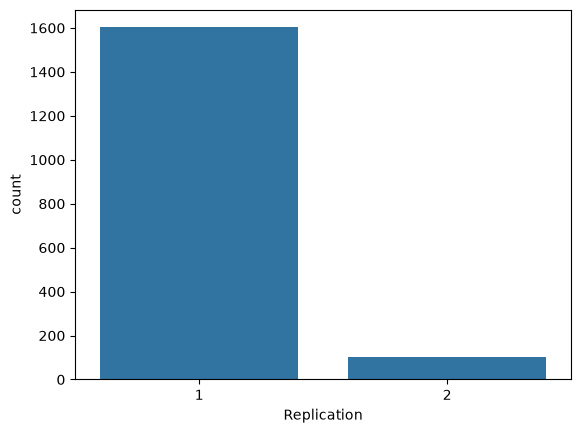

In [97]:
sns.barplot(
    data = (
        samples.loc[samples.SampleType == "Sample", :]
               .SampleId
               .value_counts()
               .rename("Replication")
               .value_counts()
               .to_frame()
    ),
    x = "Replication",
    y = "count"
)

In [104]:
replicated_samples = samples.loc[samples.SampleType == "Sample", :].SampleId.value_counts().to_frame().reset_index()
replicated_samples = replicated_samples[replicated_samples["count"] > 1]

In [198]:
replicated_samples

,SampleId,count
0,1073-17,2
1,1944-4,2
2,7889-2,2
3,6041-4,2
4,5283-13,2
...,...,...
97,4670-4,2
98,7930-4,2
99,5530-9,2
100,7500-1,2


In [293]:
nonreplicated_sample_measurements = sample_measurements.merge(
    replicated_samples.drop("count", axis = 1).merge(samples).loc[:, ["PlateId", "PlatePosition"]],
    how = "left_anti"
)
nonreplicated_sample_measurements["log2Value"] = np.log2(nonreplicated_sample_measurements["value"])

In [135]:
nonreplicated_sample_cv_by_plate = (
    100 * nonreplicated_sample_measurements.groupby(["PlateId", "SeqId"]).value.std() / nonreplicated_sample_measurements.groupby(["PlateId", "SeqId"]).value.mean()
).rename("cv").to_frame().reset_index()
nonreplicated_sample_cv_by_plate

,PlateId,SeqId,cv
0,P0031168,10000-28,409.978840
1,P0031168,10001-7,25.675626
2,P0031168,10003-15,150.244754
3,P0031168,10006-25,64.958374
4,P0031168,10008-43,34.588950
...,...,...,...
153043,P0031201,9993-11,9.893751
153044,P0031201,9994-217,36.164537
153045,P0031201,9995-6,58.456396
153046,P0031201,9997-12,54.002584


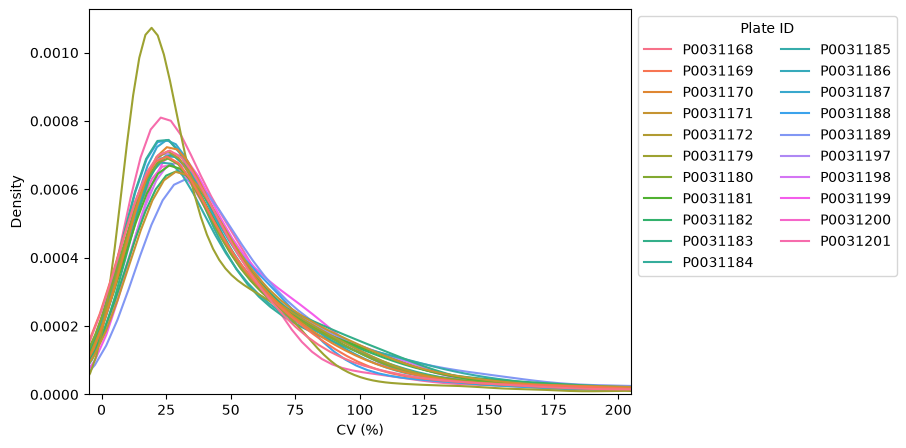

In [136]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=nonreplicated_sample_cv_by_plate,
    x="cv",
    hue="PlateId"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(
    handles,
    labels,
    title="Plate ID",
    ncol=2,
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.xlim(-5, 205)

plt.show()

In [154]:
replicated_sample_measurements = sample_measurements.merge(
    replicated_samples.drop("count", axis = 1).merge(samples).loc[:, ["PlateId", "PlatePosition"]]
)
replicated_sample_measurements["log2Value"] = np.log2(replicated_sample_measurements["value"])

In [172]:
replicated_sample_measurements_diff = (
    replicated_sample_measurements.merge(
                                      samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
                                  ).sort_values(["SampleId", "SeqId", "PlateId"])
                                  .groupby(["SampleId", "SeqId"])
                                  .log2Value
                                  .diff()
                                  .rename("log2ValueDiff")
                                  .to_frame()
)
replicated_sample_measurements_diff[["SampleId", "SeqId"]] = replicated_sample_measurements.merge(
  samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
).sort_values(["SampleId", "SeqId", "PlateId"])[["SampleId", "SeqId"]]
replicated_sample_measurements_diff = replicated_sample_measurements_diff.dropna()

In [178]:
replicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var()

SeqId
10000-28    0.006835
10001-7     0.007587
10003-15    0.104866
10006-25    0.005411
10008-43    0.003306
              ...   
9993-11     0.007525
9994-217    0.004100
9995-6      0.025179
9997-12     0.043030
9999-1      0.016361
Name: log2ValueDiff, Length: 7288, dtype: float64

In [294]:
random_matched_samples = nonreplicated_sample_measurements.loc[:, ["PlateId", "PlatePosition"]].drop_duplicates()
random_matched_samples = random_matched_samples.sample(random_matched_samples.shape[0], replace = False)
random_matched_samples["SampleId"] = np.repeat(np.arange(1, int(random_matched_samples.shape[0]/2) + 1), 2)
counts = random_matched_samples.drop_duplicates(["SampleId", "PlateId"]).SampleId.value_counts().reset_index()
random_matched_samples = random_matched_samples.merge(counts[counts["count"] == 2].head(replicated_samples.shape[0]))

In [295]:
nonreplicated_sample_measurements

,PlateId,PlatePosition,SeqId,value,log2Value
0,P0031168,A1,10000-28,799.4335,9.642834
1,P0031168,A1,10001-7,335.0557,8.388257
2,P0031168,A1,10003-15,221.4290,7.790700
3,P0031168,A1,10006-25,594.2082,9.214825
4,P0031168,A1,10008-43,746.0182,9.543067
...,...,...,...,...,...
13154835,P0031201,H8,9993-11,1142.1550,10.157543
13154836,P0031201,H8,9994-217,1480.9760,10.532333
13154837,P0031201,H8,9995-6,4750.0030,12.213713
13154838,P0031201,H8,9997-12,40241.0400,15.296380


In [291]:
random_matched_samples

,PlateId,PlatePosition,SampleId,count
0,P0031189,E3,1,2
1,P0031168,D2,1,2
2,P0031187,E4,2,2
3,P0031198,D2,2,2
4,P0031168,E6,4,2
...,...,...,...,...
199,P0031200,G2,106,2
200,P0031197,D12,107,2
201,P0031201,C12,107,2
202,P0031200,G5,108,2


In [296]:
nonreplicated_sample_measurements_diff = (
    nonreplicated_sample_measurements.merge(
                                      random_matched_samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
                                  ).sort_values(["SampleId", "SeqId", "PlateId"])
                                  .groupby(["SampleId", "SeqId"])
                                  .log2Value
                                  .diff()
                                  .rename("log2ValueDiff")
                                  .to_frame()
)
nonreplicated_sample_measurements_diff[["SampleId", "SeqId"]] = nonreplicated_sample_measurements.merge(
  random_matched_samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
).sort_values(["SampleId", "SeqId", "PlateId"])[["SampleId", "SeqId"]]
nonreplicated_sample_measurements_diff = nonreplicated_sample_measurements_diff.dropna()

In [297]:
nonreplicated_sample_measurements_diff

,log2ValueDiff,SampleId,SeqId
1450312,-0.178171,1,10000-28
1450313,-0.336091,1,10001-7
1450314,0.188747,1,10003-15
1450315,-0.299445,1,10006-25
1450316,-1.104150,1,10008-43
...,...,...,...
1450307,0.339777,108,9993-11
1450308,0.135935,108,9994-217
1450309,0.915507,108,9995-6
1450310,0.984565,108,9997-12


In [298]:
nonreplicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var()

SeqId
10000-28    0.815603
10001-7     0.523206
10003-15    0.271728
10006-25    0.196011
10008-43    0.202423
              ...   
9993-11     0.129801
9994-217    0.317698
9995-6      1.200088
9997-12     1.879872
9999-1      1.207289
Name: log2ValueDiff, Length: 7288, dtype: float64

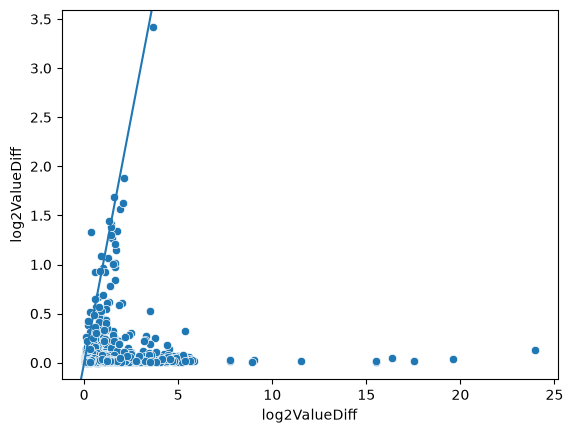

In [301]:
sns.scatterplot(
    x = nonreplicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var(),
    y = replicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var()
)

plt.axline(xy1 = [0, 0], slope = 1)